In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Configurar matplotlib
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# ============================================
# DATOS DEL EXPERIMENTO
# ============================================
data = np.array([
    [9.3, 9.4, 9.6, 10.0],  # Punta 1
    [9.4, 9.3, 9.8, 9.9],   # Punta 2
    [9.2, 9.4, 9.5, 9.7],   # Punta 3
    [9.7, 9.6, 10.0, 10.2]  # Punta 4
])

# Crear DataFrame en formato largo
df = pd.DataFrame(columns=['Punta', 'Probeta', 'Dureza'])
for i in range(4):
    for j in range(4):
        df = pd.concat([df, pd.DataFrame({
            'Punta': [f'Tip_{i+1}'],
            'Probeta': [f'Spec_{j+1}'],
            'Dureza': [data[i, j]]
        })], ignore_index=True)

print("📊 DATOS DEL EXPERIMENTO (Escala Rockwell C, codificada)")
print(df.pivot(index='Punta', columns='Probeta', values='Dureza').round(2))



📊 DATOS DEL EXPERIMENTO (Escala Rockwell C, codificada)
Probeta  Spec_1  Spec_2  Spec_3  Spec_4
Punta                                  
Tip_1       9.3     9.4     9.6    10.0
Tip_2       9.4     9.3     9.8     9.9
Tip_3       9.2     9.4     9.5     9.7
Tip_4       9.7     9.6    10.0    10.2


In [2]:
# ============================================
# PARTE (a): ANÁLISIS DE VARIANZA (RCBD)
# ============================================
print("\n" + "═"*70)
print("PARTE (a): ANÁLISIS DE VARIANZA - Diseño de Bloques Aleatorizados")
print("═"*70)

# Calcular medias
grand_mean = df['Dureza'].mean()
tip_means = df.groupby('Punta')['Dureza'].mean()
block_means = df.groupby('Probeta')['Dureza'].mean()

print(f"\n📈 Media general: {grand_mean:.4f}")
print("\n📌 Medias por punta (tratamiento):")
for tip, mean in tip_means.items():
    print(f"   {tip}: {mean:.4f}")

# Sumas de cuadrados
SST = ((df['Dureza'] - grand_mean)**2).sum()
SSTreatments = 4 * ((tip_means - grand_mean)**2).sum()
SSBlocks = 4 * ((block_means - grand_mean)**2).sum()
SSE = SST - SSTreatments - SSBlocks

# Grados de libertad
df_total = 16 - 1
df_treatments = 4 - 1
df_blocks = 4 - 1
df_error = df_total - df_treatments - df_blocks

# Cuadrados medios y estadísticos F
MS_treatments = SSTreatments / df_treatments
MS_blocks = SSBlocks / df_blocks
MS_error = SSE / df_error
F_treatments = MS_treatments / MS_error
F_blocks = MS_blocks / MS_error
p_treatments = 1 - stats.f.cdf(F_treatments, df_treatments, df_error)
p_blocks = 1 - stats.f.cdf(F_blocks, df_blocks, df_error)

print("\n📋 TABLA ANOVA:")
print(f"{'Fuente':<25} {'SC':>8} {'gl':>4} {'CM':>10} {'F':>8} {'p-valor':>10}")
print("-"*70)
print(f"{'Puntas (Tratamientos)':<25} {SSTreatments:8.4f} {df_treatments:4} {MS_treatments:10.4f} {F_treatments:8.3f} {p_treatments:10.4f}")
print(f"{'Probetas (Bloques)':<25} {SSBlocks:8.4f} {df_blocks:4} {MS_blocks:10.4f} {F_blocks:8.3f} {p_blocks:10.4f}")
print(f"{'Error':<25} {SSE:8.4f} {df_error:4} {MS_error:10.4f} {'':>8} {'':>10}")
print(f"{'Total':<25} {SST:8.4f} {df_total:4} {'':>10} {'':>8} {'':>10}")

alpha = 0.05
print(f"\n✅ CONCLUSIÓN (α = {alpha}):")
if p_treatments < alpha:
    print(f"   ✓ Existen diferencias SIGNIFICATIVAS entre las puntas (p = {p_treatments:.4f})")
else:
    print(f"   ✗ No hay evidencia de diferencias entre las puntas (p = {p_treatments:.4f})")


══════════════════════════════════════════════════════════════════════
PARTE (a): ANÁLISIS DE VARIANZA - Diseño de Bloques Aleatorizados
══════════════════════════════════════════════════════════════════════

📈 Media general: 9.6250

📌 Medias por punta (tratamiento):
   Tip_1: 9.5750
   Tip_2: 9.6000
   Tip_3: 9.4500
   Tip_4: 9.8750

📋 TABLA ANOVA:
Fuente                          SC   gl         CM        F    p-valor
----------------------------------------------------------------------
Puntas (Tratamientos)       0.3850    3     0.1283   14.437     0.0009
Probetas (Bloques)          0.8250    3     0.2750   30.937     0.0000
Error                       0.0800    9     0.0089                    
Total                       1.2900   15                               

✅ CONCLUSIÓN (α = 0.05):
   ✓ Existen diferencias SIGNIFICATIVAS entre las puntas (p = 0.0009)


In [3]:
# ============================================
# PARTE (b): MÉTODO LSD DE FISHER
# ============================================
print("\n" + "═"*70)
print("PARTE (b): COMPARACIONES MÚLTIPLES - LSD de Fisher")
print("═"*70)

t_critical = stats.t.ppf(1 - alpha/2, df_error)
LSD = t_critical * np.sqrt(2 * MS_error / 4)

print(f"\n🔢 Parámetros para LSD:")
print(f"   • t-critical (α/2, {df_error} gl) = {t_critical:.4f}")
print(f"   • CM_Error = {MS_error:.4f}")
print(f"   • LSD = {t_critical:.4f} × √(2×{MS_error:.4f}/4) = {LSD:.4f}")

print(f"\n🔍 Regla: Diferencia significativa si |mediaᵢ - mediaⱼ| > {LSD:.4f}")
print("\n📊 Comparaciones por pares:")
print(f"{'Comparación':<20} {'Diferencia':>12} {'LSD':>8} {'Resultado':>12}")
print("-"*55)

sig_diffs = []
for (tip1, tip2) in combinations(tip_means.index, 2):
    mean1, mean2 = tip_means[tip1], tip_means[tip2]
    diff = abs(mean1 - mean2)
    significant = diff > LSD
    resultado = "✓ DIFEREN" if significant else "✗ IGUALES"
    print(f"{tip1} vs {tip2:<12} {diff:12.4f} {LSD:8.4f} {resultado:>12}")
    if significant:
        sig_diffs.append(f"{tip1} vs {tip2}")

print(f"\n🎯 Puntas que difieren significativamente:")
if sig_diffs:
    for comp in sig_diffs:
        print(f"   • {comp}")
else:
    print("   • Ninguna pareja difiere significativamente")


══════════════════════════════════════════════════════════════════════
PARTE (b): COMPARACIONES MÚLTIPLES - LSD de Fisher
══════════════════════════════════════════════════════════════════════

🔢 Parámetros para LSD:
   • t-critical (α/2, 9 gl) = 2.2622
   • CM_Error = 0.0089
   • LSD = 2.2622 × √(2×0.0089/4) = 0.1508

🔍 Regla: Diferencia significativa si |mediaᵢ - mediaⱼ| > 0.1508

📊 Comparaciones por pares:
Comparación            Diferencia      LSD    Resultado
-------------------------------------------------------
Tip_1 vs Tip_2              0.0250   0.1508    ✗ IGUALES
Tip_1 vs Tip_3              0.1250   0.1508    ✗ IGUALES
Tip_1 vs Tip_4              0.3000   0.1508    ✓ DIFEREN
Tip_2 vs Tip_3              0.1500   0.1508    ✗ IGUALES
Tip_2 vs Tip_4              0.2750   0.1508    ✓ DIFEREN
Tip_3 vs Tip_4              0.4250   0.1508    ✓ DIFEREN

🎯 Puntas que difieren significativamente:
   • Tip_1 vs Tip_4
   • Tip_2 vs Tip_4
   • Tip_3 vs Tip_4


In [4]:
# ============================================
# PARTE (c): ANÁLISIS DE RESIDUALES
# ============================================
print("\n" + "═"*70)
print("PARTE (c): ANÁLISIS DE RESIDUALES")
print("═"*70)

# Calcular residuales: e_ijk = y_ijk - y_i. - y_.j + y_..
df['Residual'] = np.nan
for idx, row in df.iterrows():
    tip = row['Punta']
    block = row['Probeta']
    y_ijk = row['Dureza']
    y_i = tip_means[tip]
    y_j = block_means[block]
    residual = y_ijk - y_i - y_j + grand_mean
    df.loc[idx, 'Residual'] = residual

print("\n📐 Residuales calculados:")
residual_pivot = df.pivot(index='Punta', columns='Probeta', values='Residual')
print(residual_pivot.round(4))

print(f"\n📈 Estadísticos de residuales:")
print(f"   • Media: {df['Residual'].mean():.6f} (esperado ≈ 0)")
print(f"   • Desviación estándar: {df['Residual'].std(ddof=1):.4f}")
print(f"   • Rango: [{df['Residual'].min():.4f}, {df['Residual'].max():.4f}]")

# Pruebas de supuestos
shapiro_stat, shapiro_p = stats.shapiro(df['Residual'])
print(f"\n🧪 Prueba de normalidad (Shapiro-Wilk):")
print(f"   • W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
print(f"   • {'✓ No se rechaza normalidad' if shapiro_p > 0.05 else '✗ Evidencia de no normalidad'}")

# Levene por puntas
residuals_by_tip = [df[df['Punta']==tip]['Residual'].values for tip in df['Punta'].unique()]
levene_stat, levene_p = stats.levene(*residuals_by_tip)
print(f"\n🧪 Prueba de homogeneidad de varianzas (Levene):")
print(f"   • Estadístico = {levene_stat:.4f}, p = {levene_p:.4f}")
print(f"   • {'✓ Varianzas homogéneas' if levene_p > 0.05 else '✗ Varianzas heterogéneas'}")


══════════════════════════════════════════════════════════════════════
PARTE (c): ANÁLISIS DE RESIDUALES
══════════════════════════════════════════════════════════════════════

📐 Residuales calculados:
Probeta  Spec_1  Spec_2  Spec_3  Spec_4
Punta                                  
Tip_1    -0.050   0.025  -0.075   0.100
Tip_2     0.025  -0.100   0.100  -0.025
Tip_3    -0.025   0.150  -0.050  -0.075
Tip_4     0.050  -0.075   0.025   0.000

📈 Estadísticos de residuales:
   • Media: 0.000000 (esperado ≈ 0)
   • Desviación estándar: 0.0730
   • Rango: [-0.1000, 0.1500]

🧪 Prueba de normalidad (Shapiro-Wilk):
   • W = 0.9396, p = 0.3438
   • ✓ No se rechaza normalidad

🧪 Prueba de homogeneidad de varianzas (Levene):
   • Estadístico = 0.2182, p = 0.8819
   • ✓ Varianzas homogéneas



📊 Generando gráficos de diagnóstico...


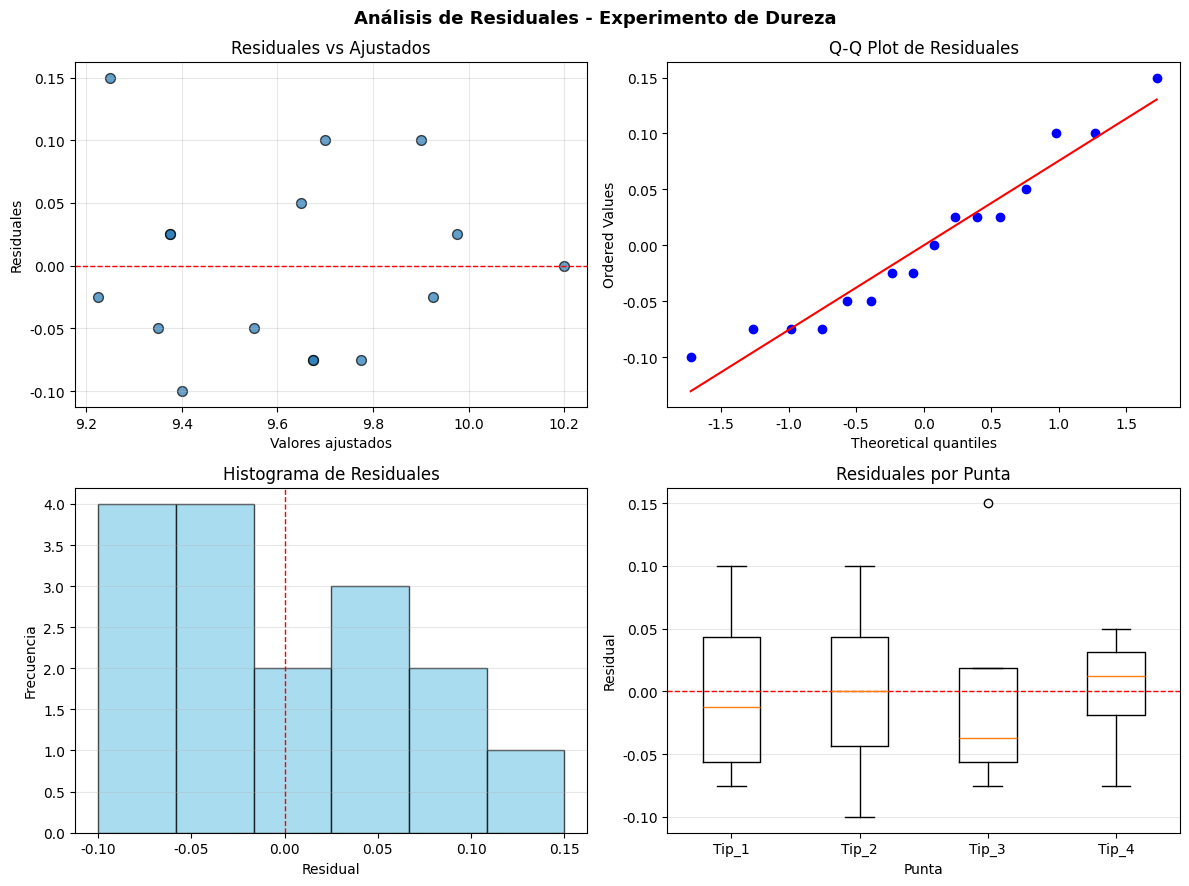

In [5]:
# ============================================
# GRÁFICOS (mostrar sin guardar)
# ============================================
print("\n📊 Generando gráficos de diagnóstico...")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Análisis de Residuales - Experimento de Dureza', fontsize=13, fontweight='bold')

# 1. Residuales vs Ajustados
df['Ajustado'] = df.apply(lambda row: tip_means[row['Punta']] + block_means[row['Probeta']] - grand_mean, axis=1)
axes[0,0].scatter(df['Ajustado'], df['Residual'], edgecolors='black', alpha=0.7, s=50)
axes[0,0].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[0,0].set_xlabel('Valores ajustados')
axes[0,0].set_ylabel('Residuales')
axes[0,0].set_title('Residuales vs Ajustados')
axes[0,0].grid(alpha=0.3)

# 2. Q-Q plot
stats.probplot(df['Residual'], dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot de Residuales')

# 3. Histograma
axes[1,0].hist(df['Residual'], bins=6, edgecolor='black', alpha=0.7, color='skyblue')
axes[1,0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1,0].set_xlabel('Residual')
axes[1,0].set_ylabel('Frecuencia')
axes[1,0].set_title('Histograma de Residuales')
axes[1,0].grid(alpha=0.3, axis='y')

# 4. Boxplot por punta
box_data = [df[df['Punta']==tip]['Residual'].values for tip in sorted(df['Punta'].unique())]
axes[1,1].boxplot(box_data, tick_labels=sorted(df['Punta'].unique()))
axes[1,1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1,1].set_xlabel('Punta')
axes[1,1].set_ylabel('Residual')
axes[1,1].set_title('Residuales por Punta')
axes[1,1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# RESUMEN FINAL
# ============================================
print("\n" + "═"*70)
print("📋 RESUMEN FINAL DEL ANÁLISIS")
print("═"*70)
print(f"""
🔹 DISEÑO EXPERIMENTAL:
   • Bloques aleatorizados completos (4 puntas × 4 probetas)
   • Variable respuesta: Dureza Rockwell C (codificada: valor - 40)

🔹 RESULTADOS DEL ANOVA:
   • Efecto Puntas: F(3,9) = {F_treatments:.3f}, p = {p_treatments:.4f}
   • Efecto Probetas: F(3,9) = {F_blocks:.3f}, p = {p_blocks:.4f}
   • Error cuadrático medio: CM_E = {MS_error:.4f}

🔹 COMPARACIONES LSD (α=0.05, LSD={LSD:.4f}):
   • Diferencias significativas encontradas en:
""")
if sig_diffs:
    for comp in sig_diffs:
        print(f"     ✓ {comp}")
else:
    print("     • Ninguna")

print(f"""
🔹 VALIDACIÓN DE SUPUESTOS:
   • Normalidad: Shapiro-Wilk p={shapiro_p:.4f} → {'✓ Cumple' if shapiro_p>0.05 else '✗ No cumple'}
   • Homogeneidad: Levene p={levene_p:.4f} → {'✓ Cumple' if levene_p>0.05 else '✗ No cumple'}
   • Independencia: Asegurada por diseño aleatorizado

🔹 INTERPRETACIÓN PRÁCTICA:
   • La punta 4 produce lecturas significativamente más altas (media = {tip_means['Tip_4']:.3f})
   • La punta 3 produce lecturas más bajas (media = {tip_means['Tip_3']:.3f})
   • Puntas 1 y 2 no difieren significativamente entre sí ni con la 3
   • {'✅ El bloqueo por probetas fue efectivo y redujo el error experimental' if p_blocks<0.05 else '⚠️ El bloqueo no fue significativo'}

🔹 RECOMENDACIÓN:
   Si se busca consistencia en mediciones, evitar usar la punta 4 junto con la 3 
   en el mismo estudio, ya que introducen un sesgo sistemático significativo.
""")

# Mostrar orden de medias
print("📊 Medias ordenadas de menor a mayor:")
ordenadas = tip_means.sort_values()
for i, (tip, mean) in enumerate(ordenadas.items(), 1):
    print(f"   {i}. {tip}: {mean:.3f}")